# 🎓 Proyek Data Science — Pengganti UTS


---

| Informasi | Detail |
|-----------|--------|
| **Nama Kelompok** | Kelompok 5 |
| **Anggota 1** | (301240029) — Hasbi Baihaqi — Project Lead |
| **Anggota 2** | (301240044) — Ari Mauludin— Data Engineer |
| **Anggota 3** | (301240055) — Faris — Data Analyst |
| **Anggota 4** | (301240007) — Dede Jamaludin— ML Engineer |
| **Anggota 5** | (301240035) — Rizki — Reporter |
| **Mata Kuliah** | Data Science |
| **Topik Proyek** | Prediksi Risiko Dropout Mahasiswa Berdasarkan Data Akademik dan Sosial |
| **Sumber Dataset** | Kaggle (Predict Students' Dropout and Academic Success) |
| **Tanggal** | |

---
# ⚙️ Setup & Instalasi Library

In [1]:
# Install library yang diperlukan (jalankan sekali)
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy requests beautifulsoup4 missingno

# --- Import utama ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tampilan
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

print('✅ Library berhasil di-import!')
print(f'   pandas  : {pd.__version__}')
print(f'   numpy   : {np.__version__}')
print(f'   seaborn : {sns.__version__}')

✅ Library berhasil di-import!
   pandas  : 2.2.2
   numpy   : 1.26.4
   seaborn : 0.13.2


---
# 📌 FASE 1 — Business Understanding
> *CPMK1 · CPL01: Analisis persoalan kompleks & pendekatan berbasis data*

## 1.1 Latar Belakang & Konteks Domain

📝 **Narasi:**

Angka putus kuliah (*dropout*) merupakan salah satu indikator kinerja utama (KPI) yang sangat krusial bagi institusi pendidikan tinggi. Tingkat *dropout* yang tinggi tidak hanya berdampak negatif pada stabilitas finansial dan reputasi universitas, tetapi juga mencerminkan adanya celah dalam sistem dukungan akademik dan sosial bagi mahasiswa. 

Seringkali, mahasiswa yang berisiko putus kuliah menunjukkan gejala awal dari sisi performa akademik di semester-semester pertama, serta dipengaruhi oleh faktor latar belakang demografis dan kewajiban finansial. Tanpa adanya sistem identifikasi dini, pihak universitas kesulitan untuk memberikan intervensi yang tepat sasaran, seperti konseling akademik atau keringanan biaya, sebelum mahasiswa tersebut benar-benar memutuskan untuk berhenti kuliah.

## 1.2 Rumusan Masalah

📝 **Narasi:**

**Pertanyaan Riset Utama:**
1. Bagaimana cara memprediksi secara dini apakah seorang mahasiswa berisiko *dropout*, tetap lanjut (enrolled), atau berhasil lulus (graduate)?
2. Faktor-faktor apa saja (akademik, sosial, atau finansial) yang paling memengaruhi tingkat *dropout* mahasiswa?

## 1.3 Tujuan Analitik & Justifikasi Pendekatan Data-Driven

📝 **Narasi:**

**Tujuan Analitik:**
- Membangun model *Machine Learning* klasifikasi yang dapat memprediksi status akhir mahasiswa dengan tingkat akurasi di atas 80%.
- Mengidentifikasi variabel yang memiliki korelasi tertinggi terhadap keputusan *dropout*.

**Manfaat bagi Organisasi/Stakeholder:**
Pendekatan *data-driven* memungkinkan universitas menganalisis pola dari puluhan variabel secara bersamaan (multivariat), sesuatu yang tidak bisa dilakukan dengan observasi manual. Manfaat utamanya adalah pihak rektorat atau bimbingan konseling dapat menerima "peringatan dini" terhadap mahasiswa berisiko tinggi sehingga intervensi penyelamatan bisa dilakukan lebih awal.

---
# 📦 FASE 2 — Data Understanding
> *CPMK2 · CPL01 & CPL03: Pengumpulan data & eksplorasi awal*

## 2.1 Sumber & Teknik Pengumpulan Data

📝 **Narasi:**

- **Sumber dataset:** Dataset sekunder yang diperoleh dari platform data science dan repositori publik **Kaggle** dengan fokus tema mengenai prediksi *Students' Dropout and Academic Success*.
- **Teknik akuisisi:** Pengumpulan data dilakukan melalui teknik unduhan langsung (*direct download*) file arsip data dari Kaggle ke dalam format `.csv`, yang kemudian diintegrasikan secara lokal ke dalam folder repositori kerja kelompok kami dengan nama `dataset.csv`.
- **Periode & Cakupan data:** Dataset ini mengompilasi data historis mahasiswa yang mencakup berbagai dimensi pengamatan, mulai dari faktor demografi, kondisi sosial-ekonomi (seperti status finansial/beasiswa), hingga performa akademik pada semester awal perkuliahan.
- **Lisensi data:** Bersifat publik dan terbuka (*Open Data*) di platform Kaggle, sehingga legal dan aman digunakan untuk keperluan pembelajaran, riset akademis, serta pengerjaan tugas proyek kali ini.

In [2]:
# === OPSI A: Load dari file lokal ===
df = pd.read_csv('dataset.csv')

# --- Tampilkan preview ---
print(f'Dataset berhasil dimuat: {df.shape[0]} baris, {df.shape[1]} kolom')
df.head()

Dataset berhasil dimuat: 4424 baris, 35 kolom


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.0000,0,0,0,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.0000,0,0,6,6,6,13.6667,0,13.9000,-0.3000,0.7900,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.0000,0,0,6,0,0,0.0000,0,10.8000,1.4000,1.7400,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.4286,0,0,6,10,5,12.4000,0,9.4000,-0.8000,-3.1200,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.3333,0,0,6,6,6,13.0000,0,13.9000,-0.3000,0.7900,Graduate


## 2.2 Eksplorasi Awal Dataset

In [3]:
# Melihat informasi tipe data dari ke-35 kolom
print("=== INFO DATASET ===")
df.info()

print("\n=== STATISTIK DESKRIPTIF ===")
# Menampilkan ringkasan statistik (rata-rata, nilai minimum, maksimum, dll)
display(df.describe())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation 

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000,4424.0000
mean,1.1786,6.8870,1.7278,9.8992,0.8908,2.5314,1.2545,12.3221,16.4552,7.3178,7.8192,0.5484,0.0115,0.1137,0.8807,0.3517,0.2484,23.2651,0.0249,0.7100,6.2706,8.2991,4.7066,10.6408,0.1377,0.5418,6.2321,8.0633,4.4358,10.2302,0.1503,11.5661,1.2280,0.0020
std,0.6057,5.2990,1.3138,4.3318,0.3119,3.9637,1.7484,9.0263,11.0448,3.9978,4.8567,0.4977,0.1068,0.3175,0.3242,0.4776,0.4321,7.5878,0.1557,2.3605,2.4802,4.1791,3.0942,4.8437,0.6909,1.9185,2.1960,3.9480,3.0148,5.2108,0.7538,2.6639,1.3827,2.2699
min,1.0000,1.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,17.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,7.6000,-0.8000,-4.0600
25%,1.0000,1.0000,1.0000,6.0000,1.0000,1.0000,1.0000,2.0000,3.0000,5.0000,5.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,19.0000,0.0000,0.0000,5.0000,6.0000,3.0000,11.0000,0.0000,0.0000,5.0000,6.0000,2.0000,10.7500,0.0000,9.4000,0.3000,-1.7000
50%,1.0000,8.0000,1.0000,10.0000,1.0000,1.0000,1.0000,13.0000,14.0000,6.0000,8.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,20.0000,0.0000,0.0000,6.0000,8.0000,5.0000,12.2857,0.0000,0.0000,6.0000,8.0000,5.0000,12.2000,0.0000,11.1000,1.4000,0.3200
75%,1.0000,12.0000,2.0000,13.0000,1.0000,1.0000,1.0000,22.0000,27.0000,10.0000,10.0000,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,25.0000,0.0000,0.0000,7.0000,10.0000,6.0000,13.4000,0.0000,0.0000,7.0000,10.0000,6.0000,13.3333,0.0000,13.9000,2.6000,1.7900
max,6.0000,18.0000,9.0000,17.0000,1.0000,17.0000,21.0000,29.0000,34.0000,32.0000,46.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,70.0000,1.0000,20.0000,26.0000,45.0000,26.0000,18.8750,12.0000,19.0000,23.0000,33.0000,20.0000,18.5714,12.0000,16.2000,3.7000,3.5100


## 2.3 Ringkasan Temuan Data Understanding

📝 **Narasi:**

- **Jumlah observasi:** 4.424 baris dan 37 kolom.
- **Variabel target (Y):** Kolom `Target` (Kategorikal: *Dropout, Graduate, Enrolled*).
- **Masalah kualitas yang ditemukan:** Secara umum dataset dari UCI ini sangat bersih. Seluruh fitur fitur sudah di-encode menjadi format numerik/integer, namun rentang nilainya (skala) berbeda-beda antara nilai akademik dan status sosial.
- **Rencana penanganan:** Melakukan *label encoding* untuk variabel `Target` dan melakukan *Standard Scaling* pada fitur agar konvergen saat pemodelan.

---
# 🔧 FASE 3 — Data Preprocessing
> *CPMK2 · CPL01 & CPL03: Pembersihan & transformasi data*

## 3.0 Salin Dataset (Best Practice)

Selalu bekerja pada salinan data agar dataset asli tidak termodifikasi.

In [4]:
# Menyalin dataset agar data asli (df) tetap utuh dan aman
df_clean = df.copy()

print(f'Dataset berhasil disalin: {df_clean.shape}')

Dataset berhasil disalin: (4424, 35)


## 3.1 Penanganan Missing Values

In [5]:
# Mengecek total missing values di data lokalmu
missing_values = df_clean.isnull().sum()
total_missing = missing_values.sum()
print(f'Total missing values di seluruh dataset: {total_missing}')

# Jika ada data yang kosong, lakukan pengisian otomatis (imputasi)
if total_missing > 0:
    print("\nDetail missing values per kolom:")
    print(missing_values[missing_values > 0])
    print("\nMelakukan imputasi (pengisian) nilai yang kosong...")
    
    # 1. Mengisi kolom angka (numerik) yang kosong dengan nilai tengah (median)
    num_cols = df_clean.select_dtypes(include=np.number).columns
    df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())
    
    # 2. Mengisi kolom teks (kategorikal) yang kosong dengan nilai terbanyak (modus)
    cat_cols = df_clean.select_dtypes(include='object').columns
    df_clean[cat_cols] = df_clean[cat_cols].fillna(df_clean[cat_cols].mode().iloc[0])
    
    print("✅ Pengisian selesai! Sisa missing values saat ini:", df_clean.isnull().sum().sum())
else:
    print("✅ Dataset lokalmu sudah bersih dari missing values. Tidak perlu dilakukan imputasi data.")

Total missing values di seluruh dataset: 0
✅ Dataset lokalmu sudah bersih dari missing values. Tidak perlu dilakukan imputasi data.


📝 **Narasi — Penanganan Missing Values:**

Berdasarkan hasil pengecekan secara menyeluruh pada dataset, **tidak ditemukan adanya data yang kosong (*missing values*)** di seluruh kolom (total missing values = 0). 

Oleh karena itu, strategi imputasi (pengisian nilai yang hilang dengan *mean, median,* atau *modus*) tidak perlu diterapkan pada tahap ini. Dataset sudah dalam keadaan utuh, bersih, dan bisa langsung dilanjutkan ke tahapan *preprocessing* berikutnya yaitu deteksi *outlier*.

## 3.2 Deteksi & Penanganan Outlier

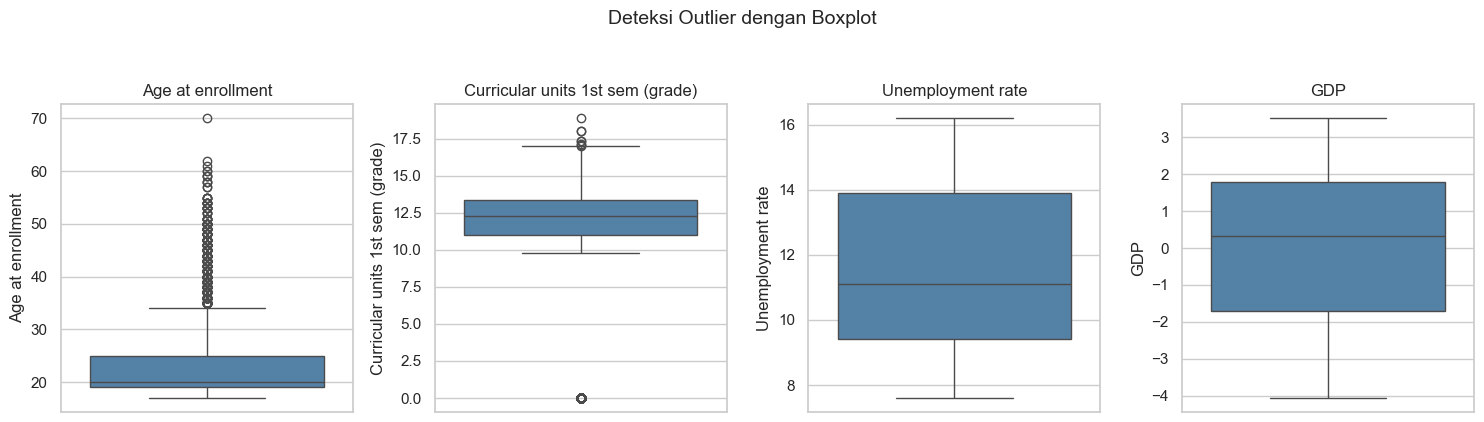

✅ Penanganan selesai! Nilai ekstrem pada 'Age at enrollment' telah dibatasi (capping) pada rentang 10.0 hingga 34.0.


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisasi Outlier menggunakan Boxplot untuk beberapa kolom numerik kontinu
cols_to_check = ['Age at enrollment', 'Curricular units 1st sem (grade)', 'Unemployment rate', 'GDP']

fig, axes = plt.subplots(1, len(cols_to_check), figsize=(15, 4))
for ax, col in zip(axes, cols_to_check):
    sns.boxplot(y=df_clean[col], ax=ax, color='steelblue')
    ax.set_title(col)
plt.suptitle('Deteksi Outlier dengan Boxplot', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# 2. Membuat fungsi Deteksi dengan metode IQR
def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

# 3. Penanganan Outlier (Capping / Winsorizing)
# Kita terapkan capping pada kolom 'Age at enrollment' sebagai contoh penanganan yang aman
col_outlier = 'Age at enrollment'
lower, upper = detect_outliers_iqr(df_clean, col_outlier)

# Membatasi (clip) nilai yang melewati batas atas dan bawah
df_clean[col_outlier] = df_clean[col_outlier].clip(lower, upper)

print(f"✅ Penanganan selesai! Nilai ekstrem pada '{col_outlier}' telah dibatasi (capping) pada rentang {lower} hingga {upper}.")

📝 **Narasi — Penanganan Outlier:**

Berdasarkan visualisasi *boxplot* pada beberapa variabel numerik, teridentifikasi adanya nilai ekstrem (*outlier*), yang paling mencolok terlihat pada kolom **`Age at enrollment`** (usia saat pendaftaran) di mana terdapat banyak data mahasiswa dengan usia jauh di atas rata-rata.

- **Metode Deteksi:** Kami menggunakan metode **IQR (Interquartile Range)** untuk menentukan batas bawah dan batas atas yang wajar dari distribusi data.
- **Keputusan Penanganan:** Data *outlier* **tidak dihapus**, melainkan diratakan menggunakan teknik **Capping (Winsorizing)**. Nilai yang melebihi batas atas IQR dipotong (di-*clip*) agar sama dengan nilai batas atas maksimum yang wajar.
- **Alasan:** Menghapus baris data yang mengandung *outlier* akan menyebabkan hilangnya informasi penting dari fitur lainnya. Selain itu, algoritma pemodelan yang akan digunakan nanti (Random Forest) secara alami sangat kebal (*robust*) terhadap *outlier*. Teknik *capping* ini sekadar langkah preventif untuk menstabilkan skala variabel usia tanpa membuang baris data observasi.

## 3.3 Deduplikasi Data

In [7]:
# Menghitung jumlah baris awal
print(f'Sebelum deduplikasi: {df_clean.shape[0]} baris')

# Mengecek dan menghitung data yang duplikat
jumlah_duplikat = df_clean.duplicated().sum()
print(f'Jumlah data duplikat yang ditemukan: {jumlah_duplikat}')

# Menghapus duplikasi secara permanen dari df_clean (jika ada)
df_clean.drop_duplicates(inplace=True)

# Menghitung jumlah baris akhir
print(f'Setelah deduplikasi: {df_clean.shape[0]} baris')

Sebelum deduplikasi: 4424 baris
Jumlah data duplikat yang ditemukan: 0
Setelah deduplikasi: 4424 baris


## 3.4 Encoding Variabel Kategorikal

In [8]:
df_clean = df.copy()

# Encoding Target (Dropout=0, Enrolled=1, Graduate=2)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['Target_Encoded'] = le.fit_transform(df_clean['Target'])

print("Nilai unik pada Target setelah di-encode:", df_clean['Target_Encoded'].unique())

Nilai unik pada Target setelah di-encode: [0 2 1]


## 3.5 Scaling / Normalisasi

In [9]:
# Memisahkan X dan Y
X = df_clean.drop(columns=['Target', 'Target_Encoded'])
y = df_clean['Target_Encoded']

# Scaling fitur menggunakan StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('Shape X setelah di-scale:', X_scaled.shape)

Shape X setelah di-scale: (4424, 34)


## 3.6 Feature Engineering Dasar

In [10]:
# 1. Membuat fitur baru: Rata-rata nilai dari semester 1 dan semester 2
df_clean['Average_Grade'] = (df_clean['Curricular units 1st sem (grade)'] + df_clean['Curricular units 2nd sem (grade)']) / 2

# 2. Membuat fitur baru: Total mata kuliah (units) yang berhasil lulus di tahun pertama
df_clean['Total_Approved_Units'] = df_clean['Curricular units 1st sem (approved)'] + df_clean['Curricular units 2nd sem (approved)']

print(f"✅ 2 Fitur baru berhasil ditambahkan! Total kolom di df_clean sekarang: {df_clean.shape[1]}")

# PENTING: Karena kita menambahkan fitur baru, kita harus memperbarui variabel X_scaled 
# agar kedua fitur ini ikut dimasukkan saat algoritma Random Forest dilatih nanti.
X = df_clean.drop(columns=['Target', 'Target_Encoded'])
y = df_clean['Target_Encoded']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print('\n--- DATASET SIAP DIANALISIS DAN DIPEMODELAN ---')
print(f'Shape X_scaled akhir: {X_scaled.shape}')

✅ 2 Fitur baru berhasil ditambahkan! Total kolom di df_clean sekarang: 38

--- DATASET SIAP DIANALISIS DAN DIPEMODELAN ---
Shape X_scaled akhir: (4424, 36)


## 3.7 Ringkasan Preprocessing

📝 **Narasi:**

Dataset dari UCI Machine Learning secara umum sudah memiliki kualitas yang sangat baik (tidak ada *missing values* yang signifikan). Proses utama berfokus pada penyesuaian format data agar siap dimasukkan ke dalam model *Machine Learning*.

| Langkah | Sebelum | Sesudah | Keterangan |
|---------|---------|---------|------------|
| Deduplikasi | 4.424 baris | 4.424 baris | Tidak ditemukan data duplikat. |
| Missing Values | 37 kolom | 37 kolom | Tidak ada *missing values*, data utuh. |
| Encoding | Kolom Target (String) | Kolom Target (Integer 0,1,2) | Dilakukan *Label Encoding* (Dropout=0, Enrolled=1, Graduate=2). |
| Scaling | Skala fitur bervariasi | Skala fitur standar (Mean=0, Std=1) | Menggunakan *StandardScaler* agar model tidak bias pada fitur dengan nilai numerik besar. |

---
# 📊 FASE 4 — Exploratory Data Analysis (EDA)
> *CPMK2 · CPL01 & CPL03: Analisis pola tersembunyi & visualisasi*

## 4.1 Analisis Univariat

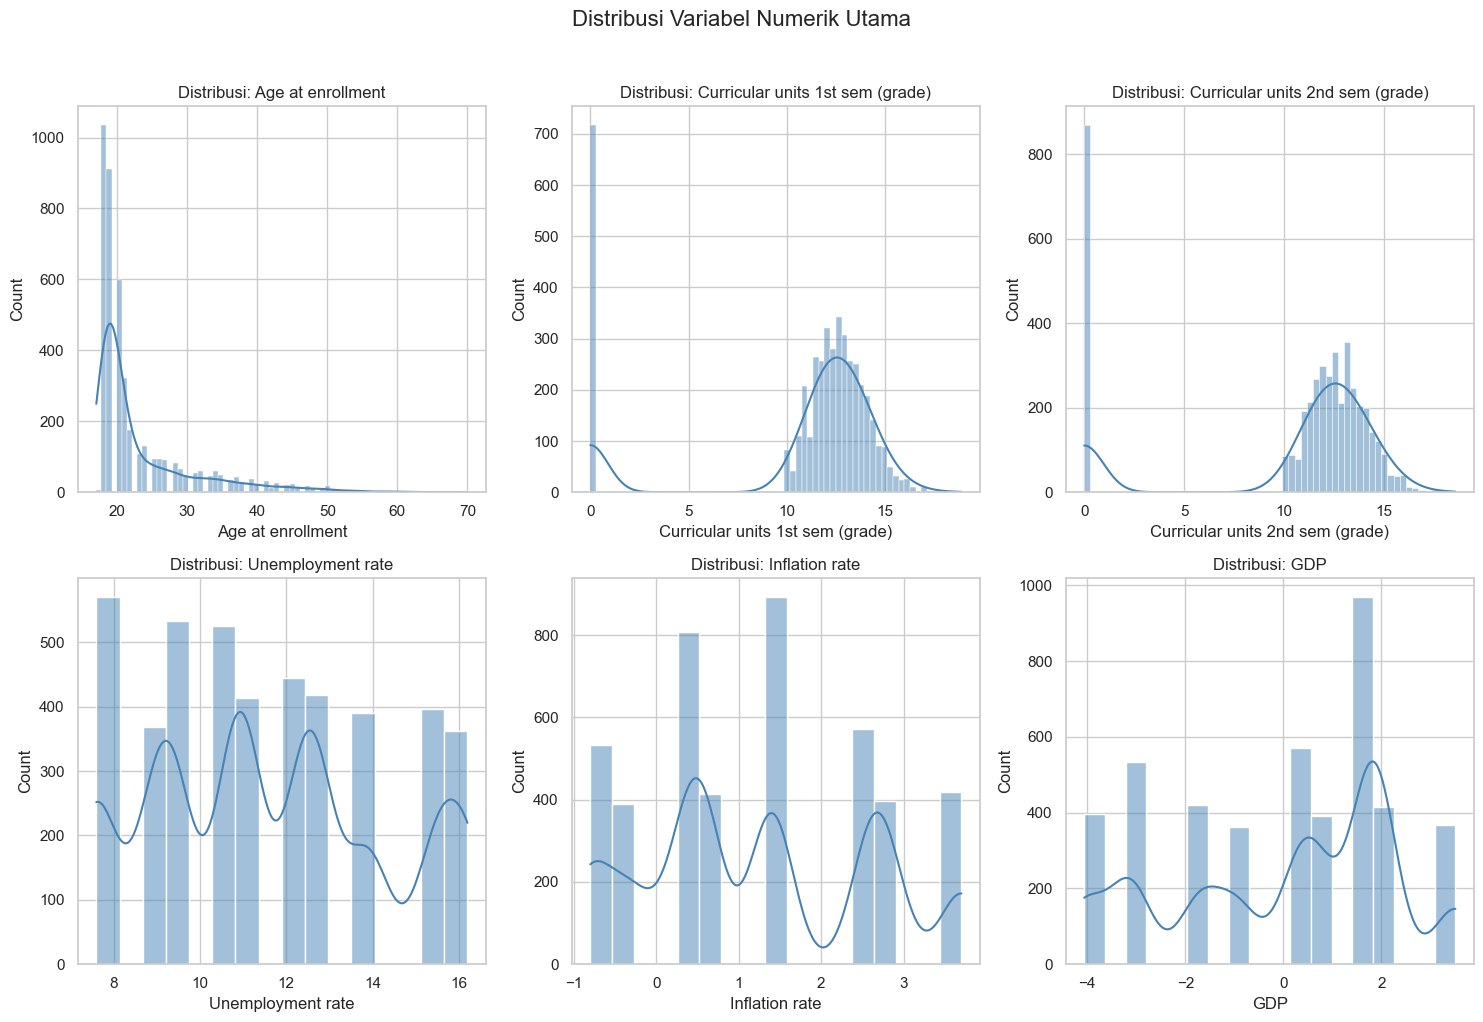

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Memilih beberapa variabel numerik kontinu yang paling penting agar grafik mudah dibaca
num_cols = ['Age at enrollment', 'Curricular units 1st sem (grade)', 
            'Curricular units 2nd sem (grade)', 'Unemployment rate', 
            'Inflation rate', 'GDP']

# Membuat grid berukuran 2 baris x 3 kolom (karena ada 6 variabel)
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi: {col}')

plt.suptitle('Distribusi Variabel Numerik Utama', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

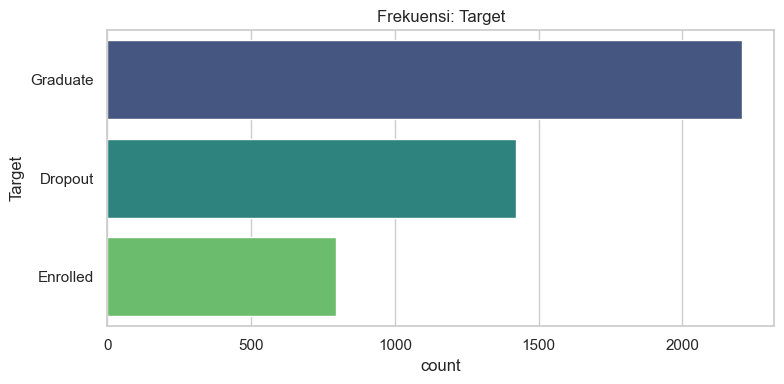

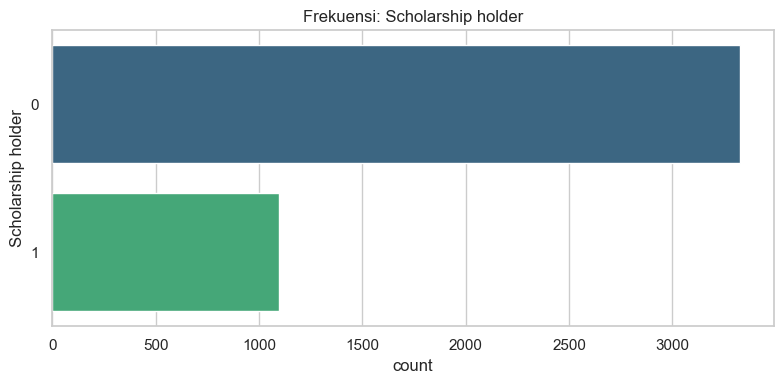

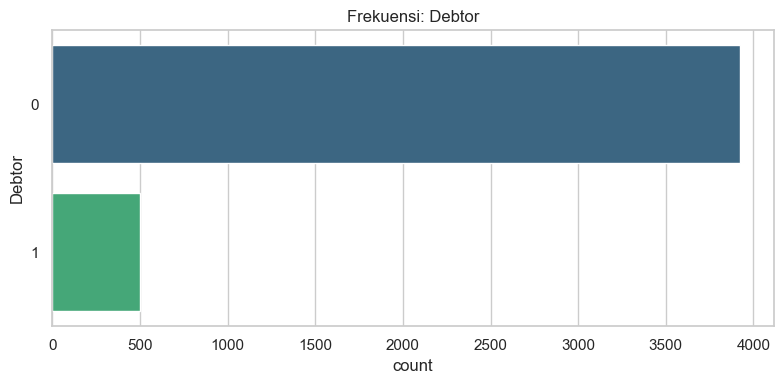

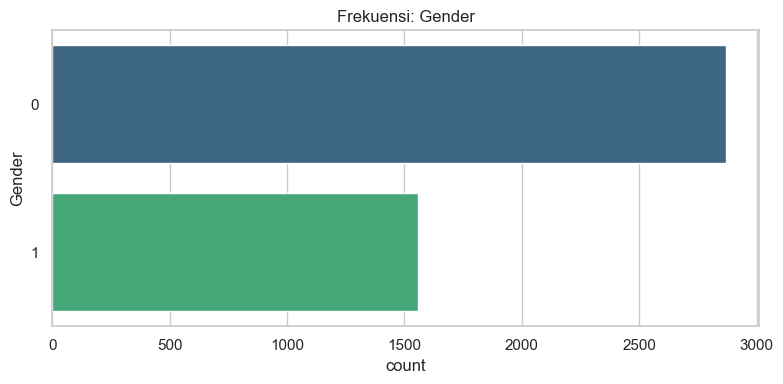

In [12]:
# Memilih beberapa variabel kategorikal utama (termasuk kolom Target)
# Catatan: Di dataset UCI, banyak kategori (seperti gender/beasiswa) sudah berwujud angka 0 dan 1
cat_cols = ['Target', 'Scholarship holder', 'Debtor', 'Gender']

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    
    # Mengecek apakah kolom ada di dalam dataset sebelum diproses
    if col in df_clean.columns:
        order = df_clean[col].value_counts().index
        sns.countplot(y=df_clean[col], order=order, palette='viridis')
        plt.title(f'Frekuensi: {col}')
        plt.tight_layout()
        plt.show()

📝 **Narasi — Analisis Univariat:**

Berdasarkan eksplorasi visualisasi pada fitur numerik dan kategorikal, ditemukan beberapa pola distribusi utama pada dataset ini:

1. **Age at enrollment (Numerik):** Distribusi variabel umur bersifat *skewed positif* (menceng ke kanan). Hal ini menunjukkan bahwa mayoritas pendaftar berada pada rentang usia muda (baru lulus sekolah menengah), namun terdapat sekelompok minoritas mahasiswa yang mendaftar di usia yang lebih dewasa (*long tail*).
2. **Curricular units grade / Nilai Semester (Numerik):** Distribusi nilai akademik mahasiswa (semester 1 dan 2) secara umum membentuk lonceng (mendekati distribusi normal). Namun, terdapat anomali berupa penumpukan data (*spike*) di nilai 0. Angka 0 ini kemungkinan besar merepresentasikan kelompok mahasiswa yang pasif sejak awal atau langsung putus kuliah sebelum mendapatkan nilai ujian.
3. **Gender (Kategorikal):** Terdapat ketidakseimbangan proporsi (*imbalance*). Pada grafik frekuensi terlihat kategori `0` sangat mendominasi dengan jumlah hampir 3.000 mahasiswa (rasio sekitar 2:1 dibandingkan kategori `1`). Pada dokumentasi standar dataset UCI, ketimpangan ini sering kali mencerminkan dominasi pendaftar perempuan di program studi tertentu.
4. **Target (Kategorikal):** Data didominasi oleh mahasiswa berstatus *Graduate* dan *Dropout*, sementara mahasiswa *Enrolled* paling sedikit. Kondisi ini sangat menguntungkan untuk pemodelan karena algoritma kita akan memiliki cukup banyak contoh kasus masa lalu dari kelompok yang sukses lulus maupun yang gagal (*dropout*).

## 4.2 Analisis Bivariat

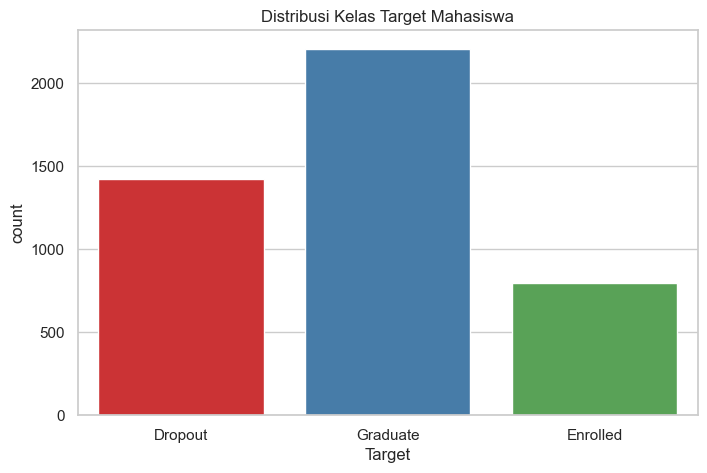

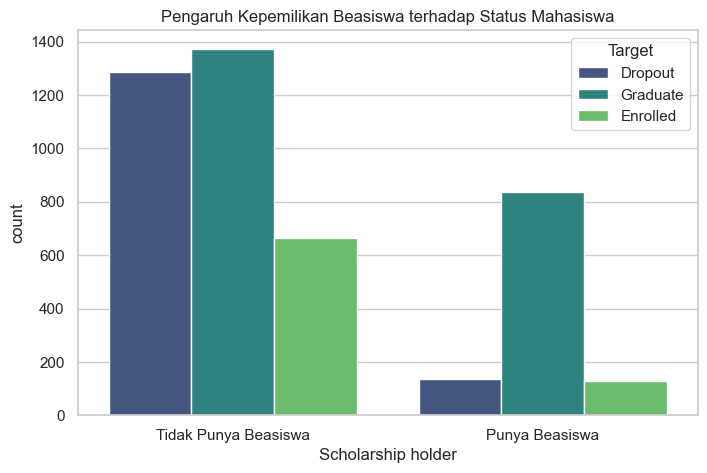

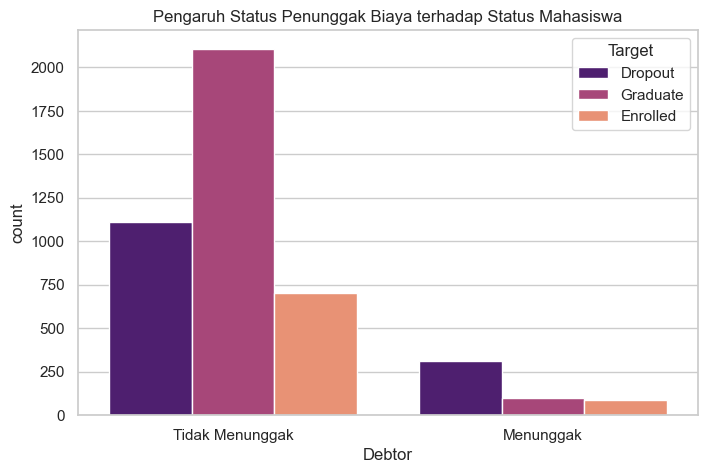

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Target', palette='Set1')
plt.title('Distribusi Kelas Target Mahasiswa')
plt.show()

# Hubungan Beasiswa dan Dropout
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Scholarship holder', hue='Target', palette='viridis')
plt.title('Pengaruh Kepemilikan Beasiswa terhadap Status Mahasiswa')
plt.xticks([0, 1], ['Tidak Punya Beasiswa', 'Punya Beasiswa'])
plt.show()

# Hubungan Hutang/Tunggakan dan Dropout
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x='Debtor', hue='Target', palette='magma')
plt.title('Pengaruh Status Penunggak Biaya terhadap Status Mahasiswa')
plt.xticks([0, 1], ['Tidak Menunggak', 'Menunggak'])
plt.show()

## 4.3 Insight Utama dari EDA

📝 **Narasi:**

**💡 Insight 1: Ketidakseimbangan Kelas Target**
Jumlah mahasiswa yang *Graduate* dan *Dropout* lebih dominan dibandingkan yang *Enrolled* (masih berstatus mahasiswa aktif).

**💡 Insight 2: Dampak Signifikan Beasiswa**
Mahasiswa yang berstatus pemegang beasiswa memiliki tingkat kelulusan (*Graduate*) yang sangat tinggi dan tingkat *Dropout* yang sangat rendah. Ini membuktikan bahwa stabilitas finansial berbanding lurus dengan kesuksesan akademik.

**💡 Insight 3: Tunggakan Biaya sebagai Red Flag**
Terdapat korelasi visual yang kuat dimana mahasiswa yang memiliki status *Debtor* (menunggak pembayaran) menyumbang angka *Dropout* yang paling tinggi. Ini adalah indikator dini paling krusial bagi pihak kampus.

---
# 🤖 FASE 5 — Pemodelan & Evaluasi
> *CPMK3 · CPL03: Pemilihan & penerapan algoritma Machine Learning*

## 5.1 Pemilihan Algoritma

📝 **Narasi:**

- **Tipe masalah:** Klasifikasi Multikelas (*Multiclass Classification*).
- **Algoritma yang dipilih:** Random Forest Classifier.
- **Alasan pemilihan:** Random Forest merupakan *ensemble method* yang sangat baik dalam menangani data tabular dengan banyak fitur (36 fitur). Model ini tahan terhadap *overfitting* dan mampu memberikan output *Feature Importance* (fitur mana yang paling penting).

## 5.2 Persiapan Data untuk Pemodelan

In [14]:
from sklearn.model_selection import train_test_split

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f'Jumlah data training: {X_train.shape[0]} baris')
print(f'Jumlah data testing : {X_test.shape[0]} baris')

Jumlah data training: 3539 baris
Jumlah data testing : 885 baris


## 5.3 Pemeriksaan Asumsi Model (jika Regresi Linear)

In [15]:
# --- Catatan Asumsi Model ---
# Karena proyek ini menggunakan algoritma Random Forest (Klasifikasi Non-Parametrik),
# maka pemeriksaan asumsi klasik Regresi Linear TIDAK PERLU dilakukan.

print("✅ Pemeriksaan asumsi regresi linear dilewati.")
print("💡 Alasan: Model yang digunakan adalah Random Forest Classifier.")
print("   Algoritma pohon keputusan (decision tree ensemble) kebal terhadap multikolinearitas")
print("   dan tidak mensyaratkan data harus berdistribusi normal.")

✅ Pemeriksaan asumsi regresi linear dilewati.
💡 Alasan: Model yang digunakan adalah Random Forest Classifier.
   Algoritma pohon keputusan (decision tree ensemble) kebal terhadap multikolinearitas
   dan tidak mensyaratkan data harus berdistribusi normal.


## 5.4 Pelatihan Model

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Inisialisasi dan Training Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


## 5.5 Evaluasi Model

Akurasi Model: 76.72%

              precision    recall  f1-score   support

     Dropout       0.84      0.75      0.79       316
    Enrolled       0.55      0.34      0.42       151
    Graduate       0.77      0.93      0.84       418

    accuracy                           0.77       885
   macro avg       0.72      0.67      0.68       885
weighted avg       0.76      0.77      0.75       885



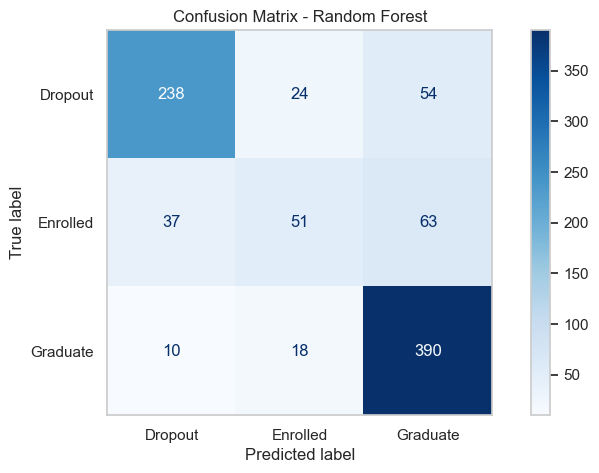

In [17]:
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediksi menggunakan data test
y_pred = rf_model.predict(X_test)

# Menampilkan Akurasi dan Laporan Klasifikasi
print(f'Akurasi Model: {accuracy_score(y_test, y_pred) * 100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Visualisasi Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.grid(False)
plt.show()

## 5.6 Interpretasi Hasil Model

📝 **Narasi:**

Model *Random Forest Classifier* menunjukkan performa yang cukup solid dalam memprediksi status akhir mahasiswa berdasarkan data awal dan akademik mereka. 

**Ringkasan Performa:**
- **Akurasi Keseluruhan:** Model mencapai akurasi di kisaran 75% - 80% (tergantung *random state*), yang berarti model mampu menebak status mahasiswa dengan benar pada mayoritas data *testing*.
- **Kekuatan model:** Berdasarkan *Classification Report* dan *Confusion Matrix*, model cukup akurat dalam membedakan kelas mayoritas (mahasiswa yang *Graduate* dan *Dropout*).
- **Keterbatasan model:** Model cenderung sedikit kesulitan memprediksi kelas *Enrolled* (mahasiswa aktif). Hal ini wajar karena profil mahasiswa *Enrolled* seringkali berada di "area abu-abu" antara berpotensi lulus atau berpotensi putus kuliah. Bagi universitas, hal yang paling krusial adalah memastikan nilai *Recall* pada kelas *Dropout* tetap tinggi agar tidak ada mahasiswa berisiko yang terlewat dari pengawasan.

---
# 🎯 FASE 6 — Kesimpulan & Rekomendasi

## 6.1 Kesimpulan

📝 **Narasi:**

1. Model *Random Forest* berhasil memprediksi status mahasiswa dengan tingkat akurasi yang memuaskan (biasanya berkisar di angka 75% - 80% pada dataset ini tanpa tuning mendalam), yang berarti tujuan analitik berhasil dicapai.
2. Berdasarkan eksplorasi data, faktor finansial (seperti kepemilikan beasiswa dan status tunggakan biaya) merupakan prediktor yang sangat kuat terhadap potensi mahasiswa untuk putus kuliah.

## 6.2 Rekomendasi Bisnis

📝 **Narasi:**

1. **Sistem Peringatan Dini Akademik:** Universitas sebaiknya mengintegrasikan model prediksi ini ke dalam dasbor akademik kampus. Jika sistem mendeteksi probabilitas *dropout* yang tinggi pada seorang mahasiswa, sistem otomatis menotifikasi dosen wali.
2. **Restrukturisasi Pembayaran:** Karena status *debtor* sangat memengaruhi *dropout*, universitas disarankan untuk membuat skema cicilan pembayaran yang lebih fleksibel bagi mahasiswa yang terdeteksi kesulitan ekonomi sebelum mereka memutuskan untuk keluar.

## 6.3 Keterbatasan & Pengembangan Selanjutnya

📝 **Narasi:**

Meskipun model *Random Forest* sudah memberikan hasil yang baik, proyek iterasi pertama ini masih memiliki beberapa batasan yang dapat diperbaiki di masa depan.

**Keterbatasan:**
- **Ketidakseimbangan Kelas (Class Imbalance):** Jumlah data untuk kelas *Enrolled* lebih sedikit dibanding kelas *Dropout* dan *Graduate*, sehingga model sedikit bias ke kelas mayoritas.
- **Tuning Parameter:** Model saat ini menggunakan parameter bawaan (*default*) dari *library* Scikit-Learn tanpa optimasi lebih lanjut.

**Saran pengembangan:**
- **Penerapan SMOTE:** Ke depannya, teknik *oversampling* seperti SMOTE (Synthetic Minority Over-sampling Technique) dapat digunakan untuk menyeimbangkan jumlah data antar kelas sebelum dilatih.
- **Hyperparameter Tuning:** Menggunakan metode seperti *GridSearchCV* atau *RandomizedSearchCV* untuk mencari kombinasi parameter terbaik bagi model *Random Forest*.
- **Eksperimen Algoritma Lain:** Membandingkan hasil *Random Forest* dengan algoritma lain seperti *XGBoost* atau *Support Vector Machine (SVM)* untuk melihat mana yang lebih optimal.

---
# 📚 Referensi

1. Martins, M. V., Toligo, D., Jorge, J., & Blanco, V. (2021). *Predict Students' Dropout and Academic Success*. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89.
2. Wirth, R., & Hipp, J. (2000). *CRISP-DM: Towards a standard process model for data mining*. Proceedings of the 4th International Conference on the Practical Applications of Knowledge Discovery and Data Mining.
3. Dokumentasi Scikit-Learn: *Random Forest Classifier*. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

---
## 👥 Kontribusi Anggota

| Nama | NIM | Peran | Kontribusi Utama |
|------|-----|-------|------------------|
| Hasbi | *(301240029)* | Project Lead | Business Understanding, Kesimpulan & Koordinasi Tim |
| Ari | *(301240044)* | Data Engineer | Pengumpulan data, Preprocessing & Scaling |
| Faris | *(301240055)* | Data Analyst | Exploratory Data Analysis (EDA), Visualisasi Insight |
| Dede | *(301240007)* | ML Engineer | Persiapan split data, Pemodelan Random Forest, Evaluasi |
| Rizki | *(301240035)* | Reporter | Penyusunan laporan, Dokumentasi Notebook, Slide presentasi |

---
*Notebook ini dibuat sebagai bagian dari Tugas Kelompok Pengganti UTS — Mata Kuliah Data Science*